In [120]:
import numpy as np
import matplotlib.pyplot as plt

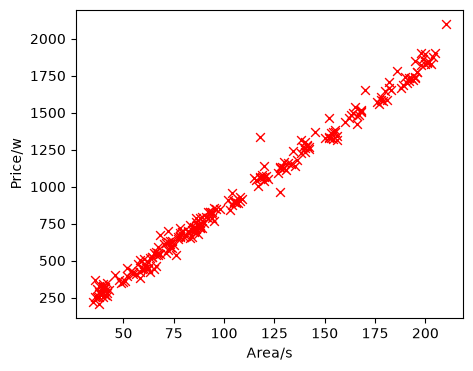

In [173]:
data = np.loadtxt("data.csv",skiprows=1,delimiter=",")
noise = np.random.normal(0,30,data.shape[0])
data[:,0] = data[:,0] + noise
plt.figure(figsize=(5,4),dpi = 100)
plt.scatter(data[:,1],data[:,0],marker='x',s=40, lw=1, color = 'r')
plt.xlabel("Area/s")
plt.ylabel("Price/w")
plt.show()

In [174]:
area = data[:,1]
area = np.column_stack((np.ones(area.shape[0]), area))
labels = data[:,0]

In [107]:
def LossFunc(theta,raw_data,labels,sigma = 1.):
    temp = 0
    gxs   = theta @ np.array(raw_data).T  # theta[1xm] @ raw_data[mxn] -> 1xn =[gx1,gx2...]
    temp = [(gxs[n] - np.array(labels)[n])**2 for n in range(raw_data.shape[0]) ]           
    return 1/(2 * sigma**2) * np.sum(temp)

def random_thetas(theta_min,theta_max,samples,shape,centered=None,radius=None):
    if centered is not None and radius is not None:
        centered = np.array(centered)
        return  [np.random.normal(loc=thea, scale=radius) for thea in centered]
    else:
        return np.random.uniform(theta_min, theta_max, size=(samples,shape))

Optimal index: 109476
Minimum loss: 1074.68
Loss range: [1074.68, 3618620858.54]
Optimal parameters: [-88.8459803    9.59697147]


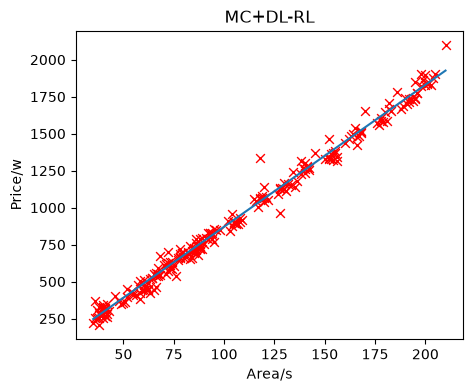

In [175]:
# Number of features 
num_features = area.shape[1]  # features = 2 (bias + area)

# Search space boundaries for random sampling
theta_max = 700
theta_min = -700
num_samples = 500000  # Number of random parameter sets to try

# 1. Randomly sample all theta vectors 
thetas = random_thetas(theta_min=theta_min,
                       theta_max=theta_max,
                       samples=num_samples,
                       shape=num_features)  # shape: (100000, 2)

# 2. Vectorized computation of all losses
# area: (n_samples, 2), thetas: (100000, 2)
# Compute predictions for all samples with all theta combinations at once
predictions = area @ thetas.T  # (n_samples, 100000) - predictions for each sample & theta

# Compute residuals (difference between predictions and actual labels)
residuals = predictions - labels.reshape(-1, 1)  # (n_samples, 100000)

# Compute Mean Squared Error (MSE) / 2 for each theta
losses = np.mean(residuals ** 2, axis=0) / 2  # (100000,) - loss for each theta

# 3. Find the optimal theta (minimum loss)
min_idx = np.argmin(losses)  # Index of theta with smallest loss
min_loss = losses[min_idx]   # Minimum loss value
max_loss = losses.max()      # Maximum loss value 
best_theta = thetas[min_idx] # Best parameter vector

# Print results
print(f"Optimal index: {min_idx}")
print(f"Minimum loss: {min_loss:.2f}")
print(f"Loss range: [{min_loss:.2f}, {max_loss:.2f}]")
print(f"Optimal parameters: {best_theta}")


def y(x):
    return best_theta[0] + best_theta[1] * x
min_a = np.min(data[:,1])
max_a = np.max(data[:,1])
x = np.linspace(min_a,max_a,data.shape[0])
plt.figure(figsize=(5,4),dpi = 100)
plt.scatter(data[:,1],data[:,0],marker='x',s=40, lw=1, color = 'r')
plt.plot(x,y(x),)
plt.xlabel("Area/s")
plt.ylabel("Price/w")
plt.title("MC+DL-RL")
plt.show()